Dataset Shape: (168, 1)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None

Dataset Head:
            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727

Dataset Description:
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


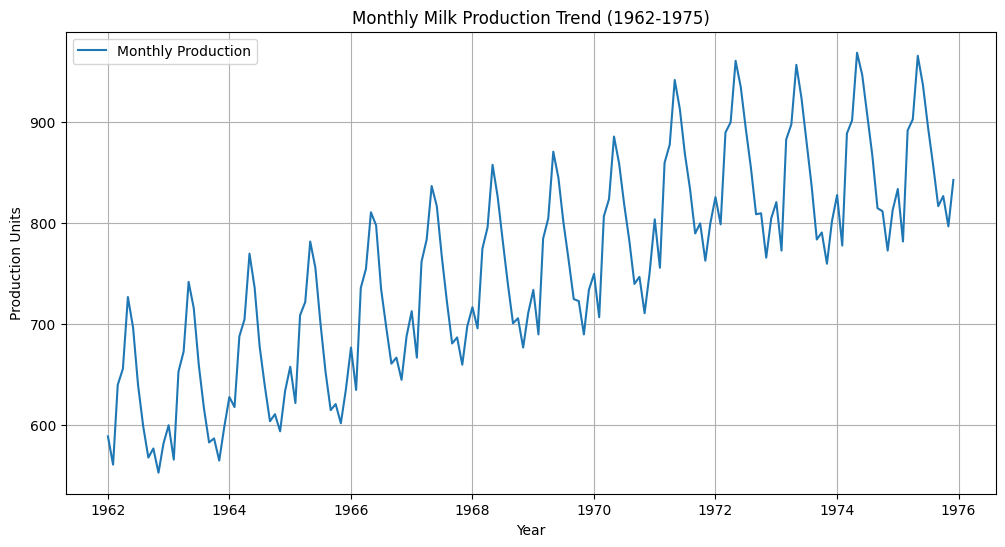

Missing Values Check:
Production    0
dtype: int64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN

# ==========================================
# 1. Load Data & Exploratory Data Analysis
# ==========================================
# Load the dataset (Ensure the file is in the same directory)
df = pd.read_csv('monthly_milk_production.csv', index_col='Date', parse_dates=True)
#shape
print(f"Dataset Shape: {df.shape}")
#info
print("\nDataset Info:")
print(df.info())
#head
print("\nDataset Head:")
print(df.head())
#describe
print("\nDataset Description:")
print(df.describe())

# Visualize the trend and seasonality
plt.figure(figsize=(12, 6))
plt.plot(df['Production'], label='Monthly Production')
plt.title('Monthly Milk Production Trend (1962-1975)')
plt.xlabel('Year')
plt.ylabel('Production Units')
plt.legend()
plt.grid(True)
plt.show()

# Check for missing values
print("Missing Values Check:")
print(df.isnull().sum())



In [5]:
# ==========================================
# 2. Data Preparation for Deep Learning
# ==========================================
# Scale the data to range [0, 1] for Neural Networks
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Function to create time-series sequences (Windowing)
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# Use 12 months (1 year) as the look-back window
window_size = 12
X, y = create_sequences(scaled_data, window_size)

# Split into Training (all but last 12 months) and Testing (last 12 months)
train_size = len(X) - 12
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Training set size: 144
Testing set size: 12


In [6]:
# ==========================================
# 3. Model Building (RNN, LSTM, GRU)
# ==========================================
def build_model(model_type):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(64, activation='relu', input_shape=(window_size, 1)))
    elif model_type == 'LSTM':
        model.add(LSTM(64, activation='relu', input_shape=(window_size, 1)))
    elif model_type == 'GRU':
        model.add(GRU(64, activation='relu', input_shape=(window_size, 1)))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Train the models
models = {}
for m_type in ['RNN', 'LSTM', 'GRU']:
    print(f"Training {m_type} Model...")
    model = build_model(m_type)
    model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)
    models[m_type] = model


Training RNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM Model...
Training GRU Model...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step

Evaluation Metrics Comparison:
  Model       RMSE        MAE      MAPE
0   RNN  10.643174   9.079132  0.010840
1  LSTM  25.473358  21.038198  0.024795
2   GRU  31.777946  23.330485  0.027613


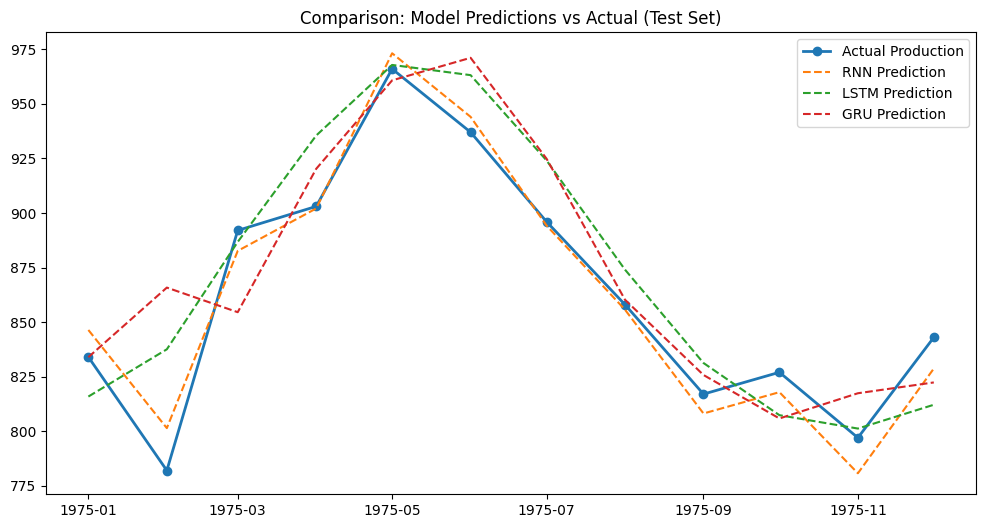

In [7]:
# ==========================================
# 4. Model Evaluation & Comparison
# ==========================================
results = []
predictions_dict = {}

for name, model in models.items():
    # Make predictions on test set
    preds = model.predict(X_test)

    # Inverse transform to get actual production values
    preds_rescaled = scaler.inverse_transform(preds)
    actual_rescaled = scaler.inverse_transform(y_test)

    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(actual_rescaled, preds_rescaled))
    mae = mean_absolute_error(actual_rescaled, preds_rescaled)
    mape = mean_absolute_percentage_error(actual_rescaled, preds_rescaled)

    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})
    predictions_dict[name] = preds_rescaled

# Display Evaluation Table
eval_df = pd.DataFrame(results)
print("\nEvaluation Metrics Comparison:")
print(eval_df)

# Plot Test Predictions vs Actual
plt.figure(figsize=(12, 6))
test_dates = df.index[-12:]
plt.plot(test_dates, scaler.inverse_transform(y_test), label='Actual Production', marker='o', linewidth=2)
for name, preds in predictions_dict.items():
    plt.plot(test_dates, preds, label=f'{name} Prediction', linestyle='--')
plt.title('Comparison: Model Predictions vs Actual (Test Set)')
plt.legend()
plt.show()

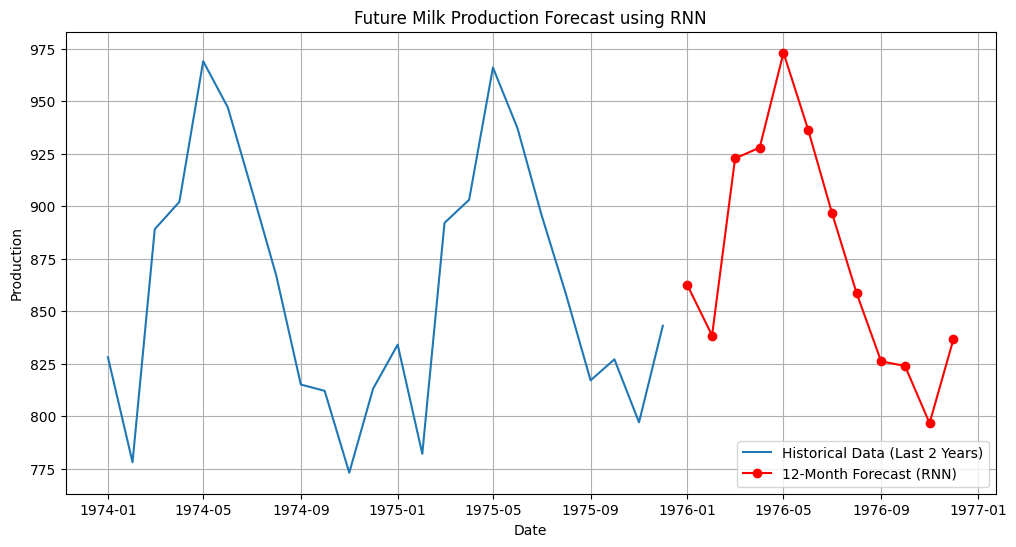


12-Month Future Forecast (1976):
1976-01: 862.28
1976-02: 838.36
1976-03: 922.71
1976-04: 927.82
1976-05: 973.04
1976-06: 936.43
1976-07: 896.80
1976-08: 858.61
1976-09: 826.03
1976-10: 823.88
1976-11: 796.62
1976-12: 836.46


In [8]:
# ==========================================
# 5. Future Forecasting (Next 12 Months)
# ==========================================
# Identify the best model based on RMSE
best_model_name = eval_df.sort_values('RMSE').iloc[0]['Model']
best_model = models[best_model_name]

def forecast_future(model, last_sequence, n_steps):
    forecast = []
    current_seq = last_sequence.copy()

    for _ in range(n_steps):
        # Predict the next month
        pred = model.predict(current_seq.reshape(1, window_size, 1), verbose=0)
        forecast.append(pred[0, 0])
        # Slide window: Remove first, append prediction to the end
        current_seq = np.append(current_seq[1:], pred).reshape(window_size, 1)

    return scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

# Get last available 12 months from original data to start forecasting
last_window = scaled_data[-window_size:]
future_forecast = forecast_future(best_model, last_window, 12)

# Create dates for the next 12 months
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Visualize Future Forecast
plt.figure(figsize=(12, 6))
plt.plot(df.index[-24:], df['Production'].tail(24), label='Historical Data (Last 2 Years)')
plt.plot(future_dates, future_forecast, label=f'12-Month Forecast ({best_model_name})', color='red', marker='o')
plt.title(f'Future Milk Production Forecast using {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()

print("\n12-Month Future Forecast (1976):")
for date, val in zip(future_dates, future_forecast):
    print(f"{date.strftime('%Y-%m')}: {val[0]:.2f}")